<a href="https://colab.research.google.com/github/M-marshiro/Fliprobo-Projects/blob/main/Homework6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
!python -m textblob.download_corpora

[nltk_data] Downloading package brown to /root/nltk_data...
[nltk_data]   Package brown is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package conll2000 to /root/nltk_data...
[nltk_data]   Package conll2000 is already up-to-date!
[nltk_data] Downloading package movie_reviews to /root/nltk_data...
[nltk_data]   Package movie_reviews is already up-to-date!
Finished.


In [16]:
import nltk

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [17]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import imageio
from textblob import TextBlob
from nltk.corpus import stopwords
from operator import itemgetter
from wordcloud import WordCloud

In [18]:
target_url = 'https://www.gutenberg.org/files/2265/2265-0.txt'

response = requests.get(target_url)

data = response.text

In [19]:
print(data[:1000])

*** START OF THE PROJECT GUTENBERG EBOOK 2265 ***


Executive Director's Notes:

In addition to the notes below, and so you will *NOT* think all
the spelling errors introduced by the printers of the time have
been corrected, here are the first few lines of Hamlet, as they
are presented herein:

  Barnardo. Who's there?
  Fran. Nay answer me: Stand & vnfold
your selfe

   Bar. Long liue the King

       *       *       *       *       *

As I understand it, the printers often ran out of certain words
or letters they had often packed into a "cliche". . .this is the
original meaning of the term cliche. . .and thus, being unwilling
to unpack the cliches, and thus you will see some substitutions
that look very odd. . .such as the exchanges of u for v, v for u,
above. . .and you may wonder why they did it this way, presuming
Shakespeare did not actually write the play in this manner. . . .

The answer is that they MAY have packed "liue" into a cliche at a
time when


In [20]:
blob = TextBlob(data)

In [21]:
stop_words = stopwords.words('english')

In [22]:
items = blob.word_counts.items()

In [23]:
items = [
    item for item in items
    if item[0] not in stop_words and item[0].isalpha()
]

In [24]:
sorted_items = sorted(
    items,
    key=itemgetter(1),
    reverse=True
)

sorted_items[:25]

[('ham', 337),
 ('lord', 211),
 ('haue', 175),
 ('king', 173),
 ('shall', 107),
 ('come', 106),
 ('thou', 105),
 ('let', 104),
 ('hamlet', 100),
 ('good', 98),
 ('hor', 95),
 ('thy', 90),
 ('enter', 85),
 ('oh', 81),
 ('like', 78),
 ('well', 70),
 ('may', 69),
 ('know', 69),
 ('selfe', 68),
 ('would', 68),
 ('loue', 65),
 ('vs', 64),
 ('sir', 62),
 ('qu', 62),
 ('laer', 60)]

In [25]:
top20 = sorted_items[:20]

top20

[('ham', 337),
 ('lord', 211),
 ('haue', 175),
 ('king', 173),
 ('shall', 107),
 ('come', 106),
 ('thou', 105),
 ('let', 104),
 ('hamlet', 100),
 ('good', 98),
 ('hor', 95),
 ('thy', 90),
 ('enter', 85),
 ('oh', 81),
 ('like', 78),
 ('well', 70),
 ('may', 69),
 ('know', 69),
 ('selfe', 68),
 ('would', 68)]

In [26]:
df = pd.DataFrame(
    top20,
    columns=['word', 'count']
)

df

,word,count
0,ham,337
1,lord,211
2,haue,175
3,king,173
4,shall,107
5,come,106
6,thou,105
7,let,104
8,hamlet,100
9,good,98


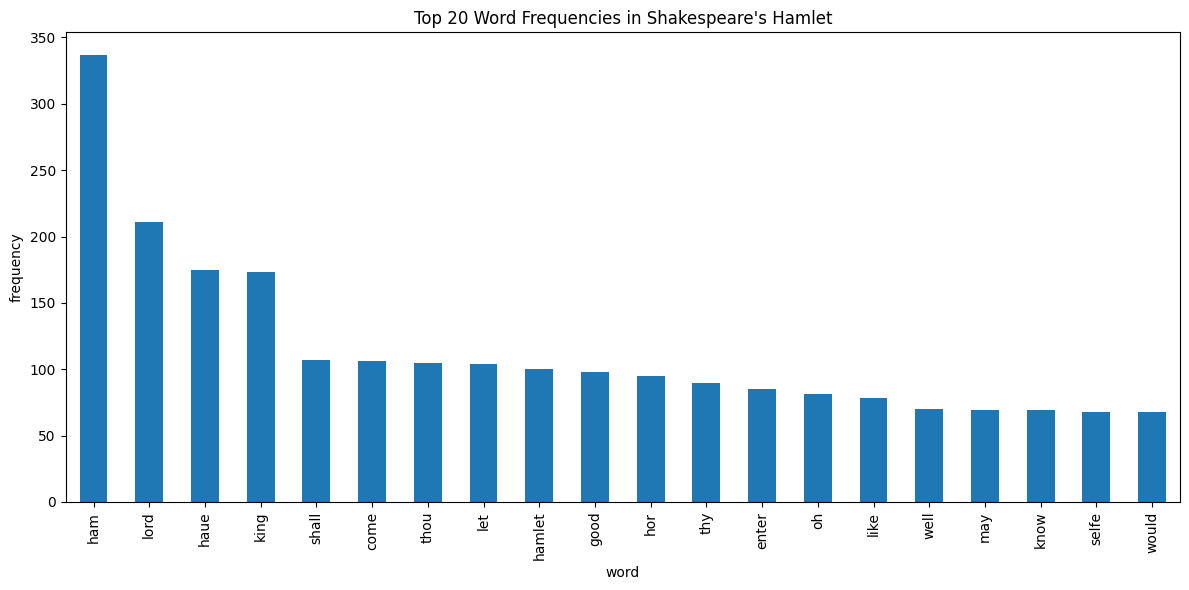

In [27]:
axes = df.plot.bar(
    x='word',
    y='count',
    legend=False,
    figsize=(12, 6)
)

plt.xlabel('word')
plt.ylabel('frequency')
plt.title("Top 20 Word Frequencies in Shakespeare's Hamlet")

plt.gcf().tight_layout()

plt.show()

In [28]:
image_file = "https://media.cheggcdn.com/media/216/21621ee5-e80f-47f3-9145-513f2229b390/phploeBuh.png"

mask_image = imageio.v3.imread(image_file)

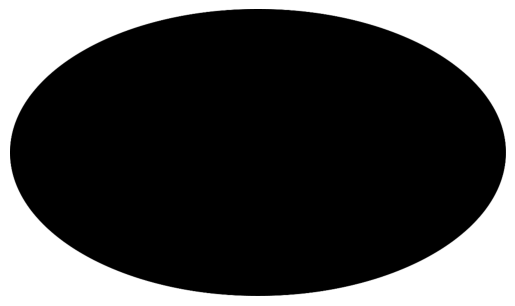

In [29]:
plt.imshow(mask_image)
plt.axis('off')
plt.show()

In [30]:
wordcloud = WordCloud(
    colormap='prism',
    mask=mask_image,
    background_color='white'
)

In [31]:
wordcloud = wordcloud.generate(data)

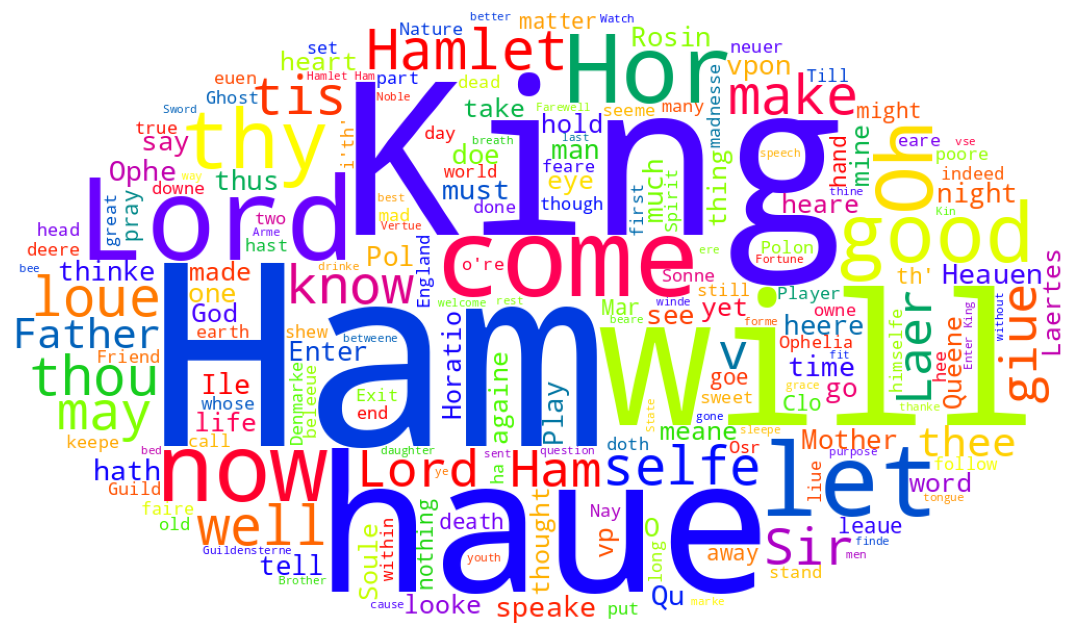

In [32]:
plt.figure(figsize=(14, 8))

plt.imshow(wordcloud)

plt.axis('off')

plt.show()